In [11]:
import pipeline.calculate_metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gerrychain.grid
import random
from collections import deque
import warnings
pd.set_option('display.max_columns', None)
from itertools import combinations
from matplotlib.lines import Line2D


In [12]:
black = pd.read_csv("outputs/white_black_parsed.csv")
poc = pd.read_csv("outputs/white_poc_parsed.csv")

In [13]:
#at present there are multiple rows for each cbsa-year pair corresponding to different vintages
#this filters for April 2018 vintage
poc = poc[poc["filename"].str.contains("april_2018")]

In [14]:
#pick the 100 most populous metro areas
#df_2010 = poc[poc["year"] == 2010]
#df_2010.sort_values("total_population", inplace= True, ascending = False)
#top_100 = df_2010.head(100)

In [15]:


#First pick (w/out replacement) the 40 most populous, then pick 60 most diverse
df_2010 = poc[poc["year"]==2010]
#calculate diversity
df_2010["blau"] = 1 - ((df_2010["total_black"] / df_2010["total_population"])**2 +
                        (df_2010["total_white"] / df_2010["total_population"])**2 +
                        (df_2010["total_asian"] / df_2010["total_population"])**2 +
                        (df_2010["total_amin"] / df_2010["total_population"])**2 +
                        (df_2010["total_population"] - (df_2010["total_black"] + df_2010["total_white"] + df_2010["total_asian"] + df_2010["total_amin"])/ df_2010["total_population"])**2
                        )

#pick forty most populous cities
df_2010 = df_2010.sort_values("total_population",  ascending = False)
top_40 = df_2010.head(40)
df_2010_dropped = df_2010.iloc[40:].reset_index(drop=True)

#pick the 60 most diverse cities not in the 40 most populous
df_2010 = df_2010_dropped.sort_values("blau", ascending = False)
top_60 = df_2010_dropped.head(60)

#combine
top_100 = pd.concat([top_40, top_60], ignore_index=True)

Fig 7.

In [16]:
pd.set_option('display.max_columns', None)

In [17]:
name_map = {
    14460: "Boston",
    16980: "Chicago",
    19820: "Detroit",
    35620: "NYC",
    29820: "Las Vegas",
}

In [18]:
cities_big = [
    (14460, "Boston"),
    (16980, "Chicago"),
    (19820, "Detroit"),
    (35620, "NYC"),
    (29820, "Las Vegas")
    ]

In [19]:
for city in cities_big:
    n = len(poc[poc["cbsa_code"] == city[0]])
    print(city, n)

(14460, 'Boston') 6
(16980, 'Chicago') 6
(19820, 'Detroit') 6
(35620, 'NYC') 6
(29820, 'Las Vegas') 6


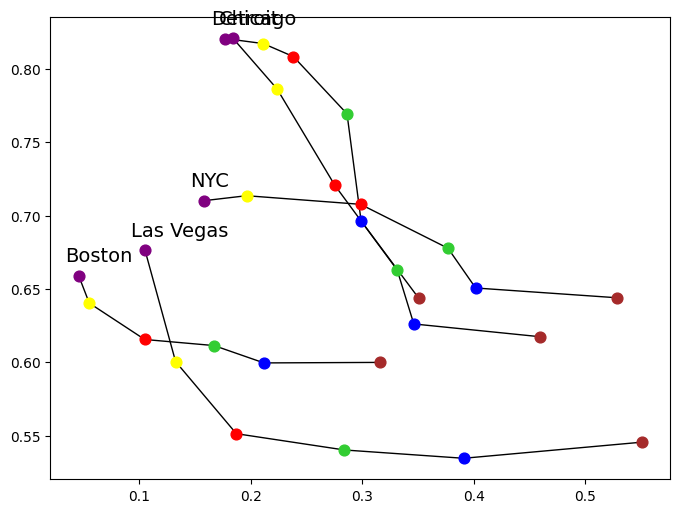

In [20]:
colors = {
    1970: "purple",
    1980: "yellow",
    1990: "red",
    2000: "limegreen",
    2010: "blue",
    2020: "brown"
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_big:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    
    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )



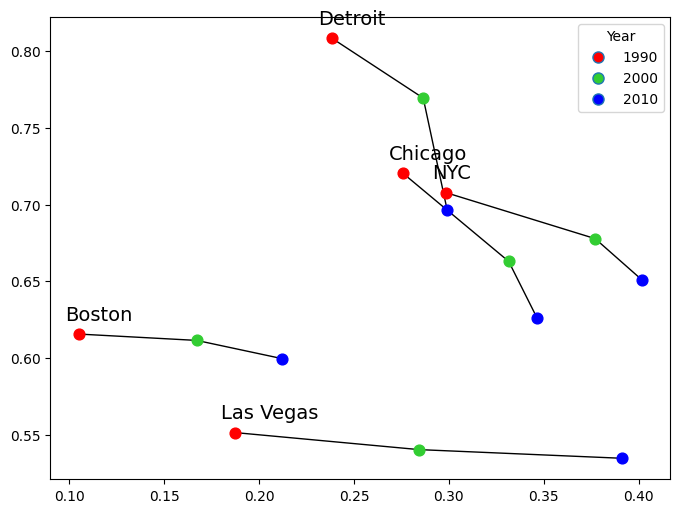

In [23]:
cities_big = [
    (14460, "Boston"),
    (16980, "Chicago"),
    (19820, "Detroit"),
    (35620, "NYC"),
    (29820, "Las Vegas")
    ]

colors = {
    1990: "red",
    2000: "limegreen",
    2010: "blue",
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_big:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
    )
    city_df = (
        city_df[city_df["year"].isin((1990, 2000, 2010))]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            label=str(year),
            markerfacecolor=color,
            markersize=8
        )
        for year, color in colors.items()
    ]

    ax.legend(handles=legend_elements, title="Year")

    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )

In [26]:
cities_small = [
    (33340, "Milwaukee"),
    (13820, "Birmingham"),
    (22420, "Flint"),
    (35300, "New Haven"),
    (43780, "South Bend")
    ]

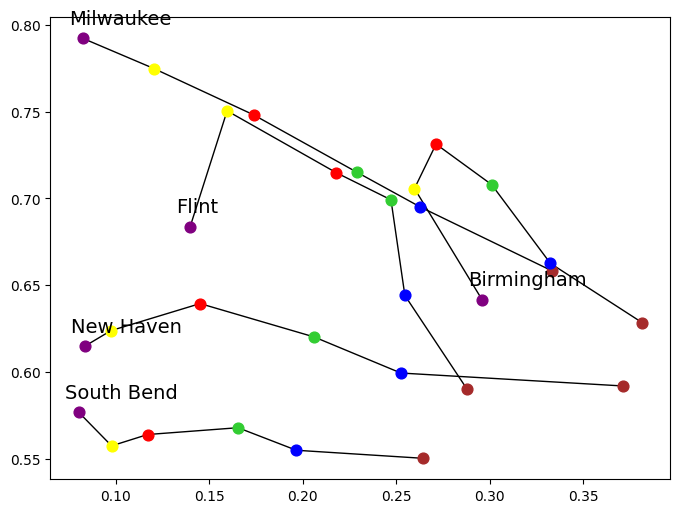

In [27]:
colors = {
    1970: "purple",
    1980: "yellow",
    1990: "red",
    2000: "limegreen",
    2010: "blue",
    2020: "brown"
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_small:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    
    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )


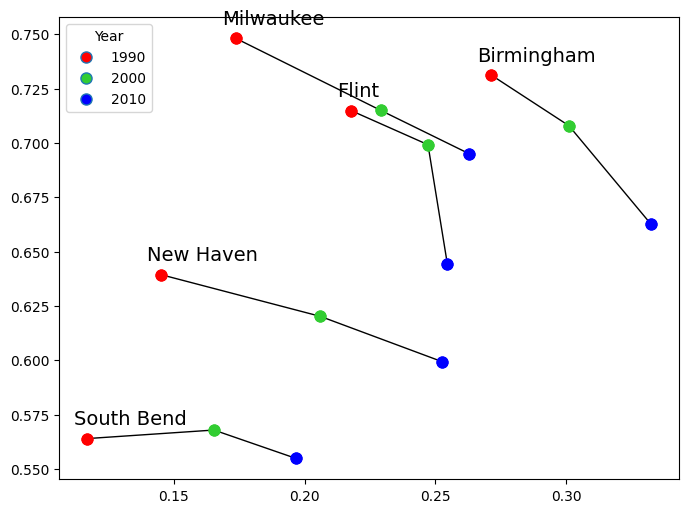

In [29]:
cities_small = [
    (33340, "Milwaukee"),
    (13820, "Birmingham"),
    (22420, "Flint"),
    (35300, "New Haven"),
    (43780, "South Bend")
    ]

colors = {
    1990: "red",
    2000: "limegreen",
    2010: "blue",
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_small:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
    )
    city_df = (
        city_df[city_df["year"].isin((1990, 2000, 2010))]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            label = colors[row["year"]],
            s=60,
            zorder=3
        )
    
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            label=str(year),
            markerfacecolor=color,
            markersize=8
        )
        for year, color in colors.items()
    ]

    ax.legend(handles=legend_elements, title="Year")

    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )

Fig 8.

In [30]:
def rankr(x_score, y_score, label_x = None, label_y = None, best_fit = True, df = top_100):
    if label_x == None:
        label_x = x_score
    if label_y == None:
        label_y = y_score   

    y = df[[y_score, "cbsa_code"]].sort_values(y_score)
    y.sort_values(y_score, inplace = True)

    x = df[[x_score, "cbsa_code"]].sort_values(x_score)
    x.sort_values(x_score, inplace = True)

    x = x.reset_index(drop=True)
    x["rank_x"] = np.arange(1, len(x) + 1)

    # y is already sorted by score 2
    y = y.reset_index(drop=True)
    y["rank_y"] = np.arange(1, len(y) + 1)

    # keep only cbsa and ranks
    ranks = x[["cbsa_code", "rank_x"]].merge(
        y[["cbsa_code", "rank_y"]],
        on="cbsa_code"
        )

    # fit line y = mx + b
    m, b = np.polyfit(ranks["rank_x"], ranks["rank_y"], 1)

    # scatterplot   
    plt.scatter(ranks["rank_x"], ranks["rank_y"])

    # best-fit line
    if best_fit == True:
        x_line = np.linspace(ranks["rank_x"].min(), ranks["rank_x"].max(), 100)
        plt.plot(x_line, m * x_line + b)

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()

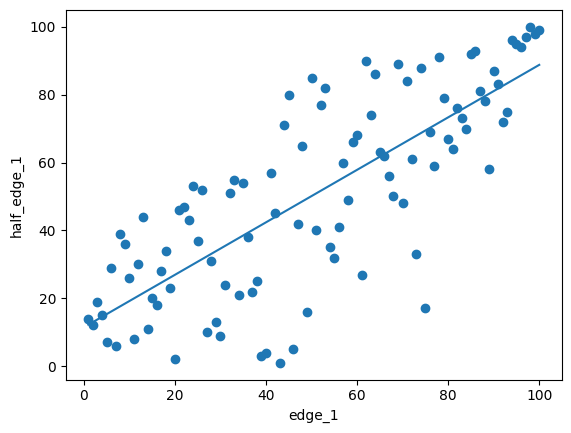

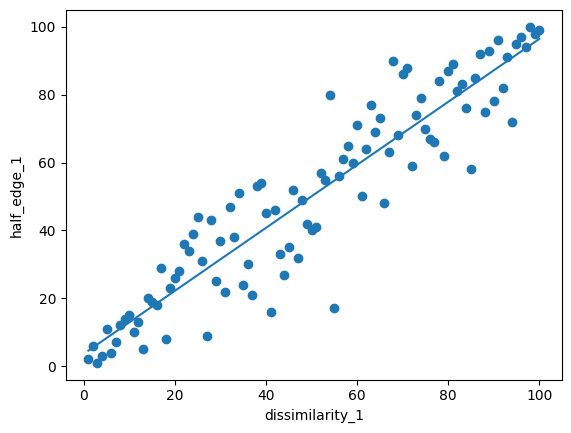

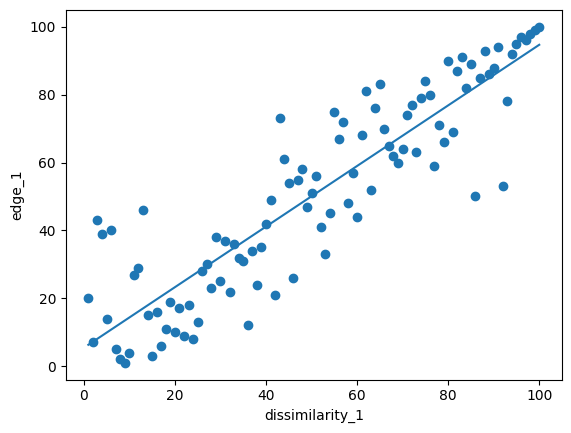

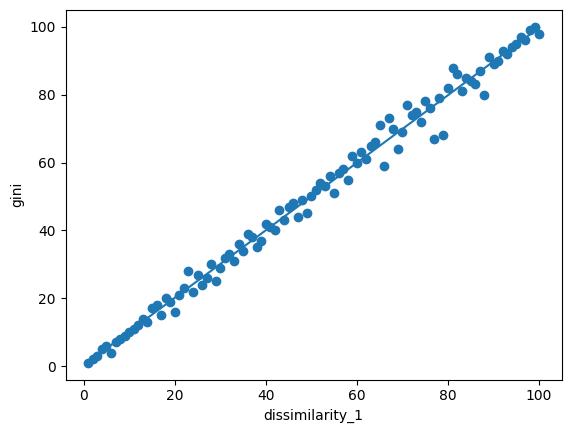

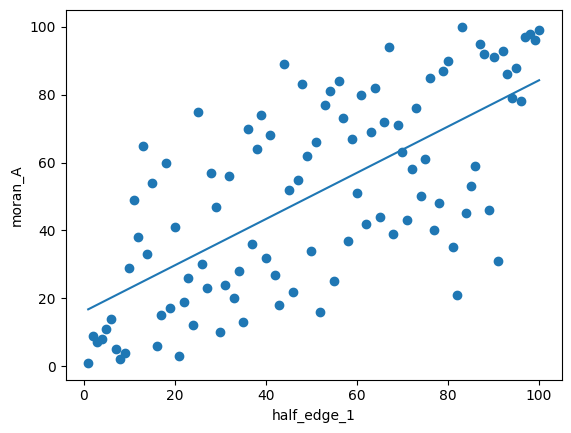

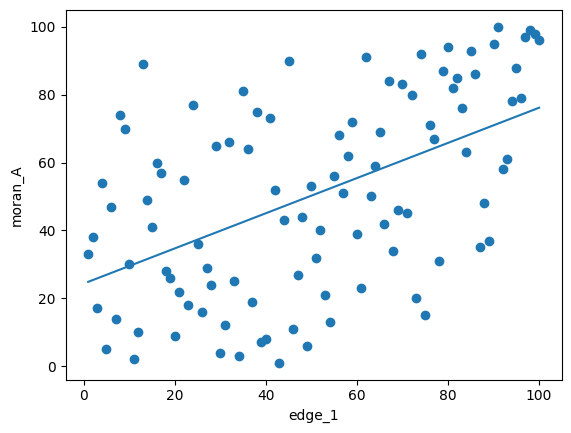

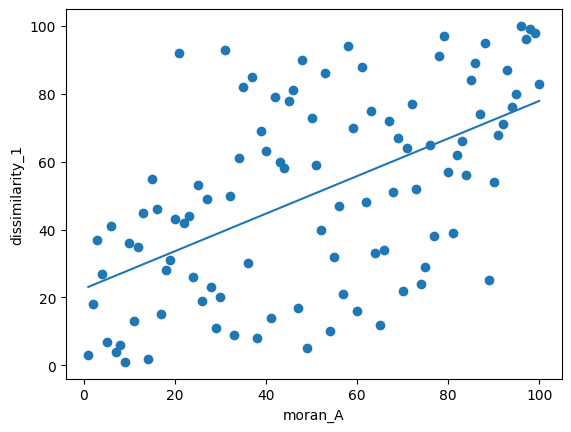

In [31]:
score_pairs = [("edge_1", "half_edge_1"), 
               ("dissimilarity_1", "half_edge_1"),
               ("dissimilarity_1", "edge_1"),
               ("dissimilarity_1", "gini"),
               ("half_edge_1", "moran_A"),
               ("edge_1", "moran_A"),
               ("moran_A", "dissimilarity_1")]

for pair in score_pairs:
    rankr(pair[0], pair[1])

Fig 10

In [32]:
def plotr(x_var, y_var, label_x = None, label_y = None, df = top_100):
    if label_x == None:
        label_x = x_var
    if label_y == None:
        label_y = y_var 

    # scatterplot   
    plt.scatter(df[x_var], df[y_var])

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()
    

In [33]:
small_pop = top_100[top_100["total_population"] <= 1800000]

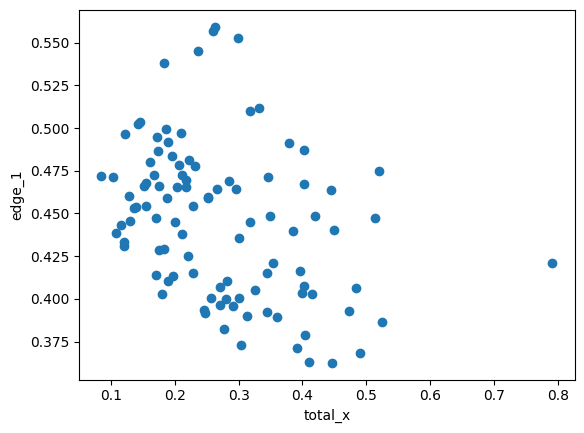

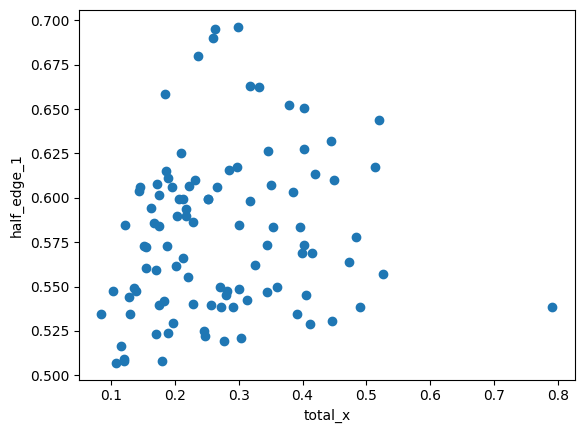

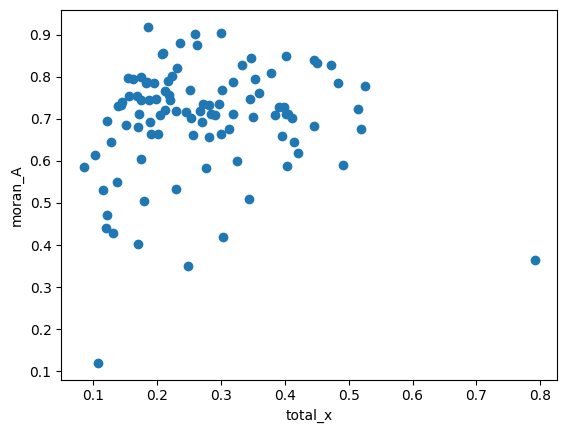

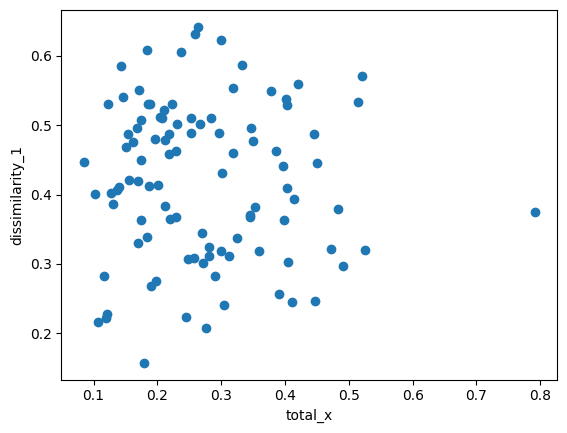

In [34]:
scores = ["edge_1", "half_edge_1", "moran_A", "dissimilarity_1"]

for score in scores:
    plotr("total_x", score)

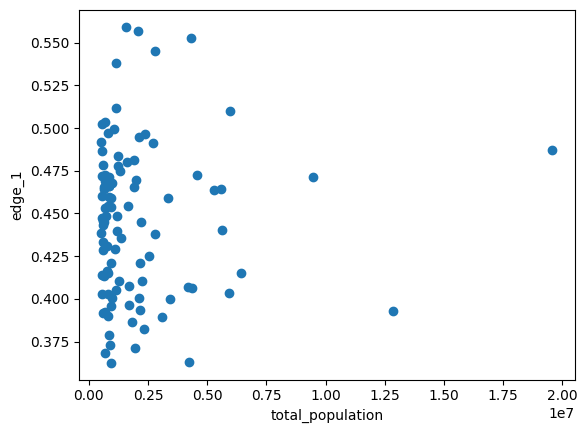

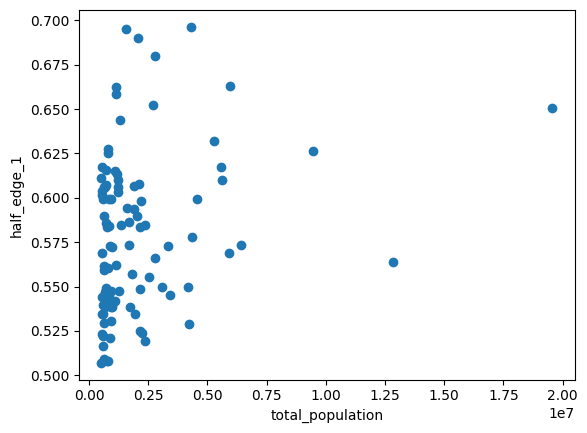

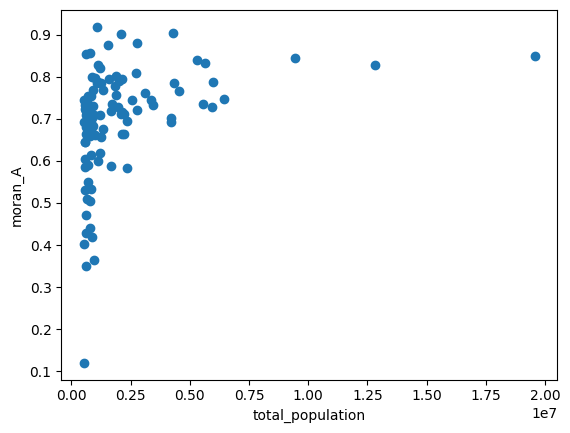

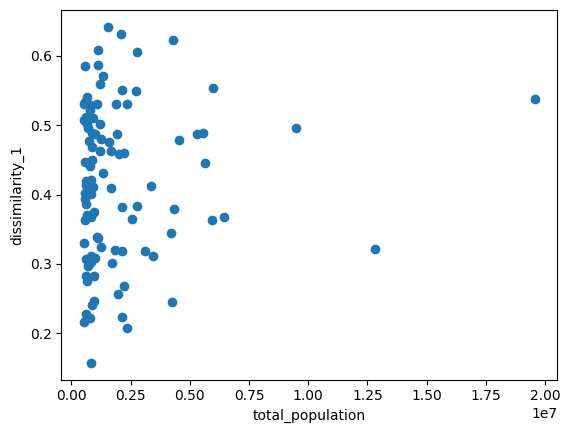

In [36]:
scores = ["edge_1", "half_edge_1", "moran_A", "dissimilarity_1"]

for score in scores:
    plotr("total_population", score)

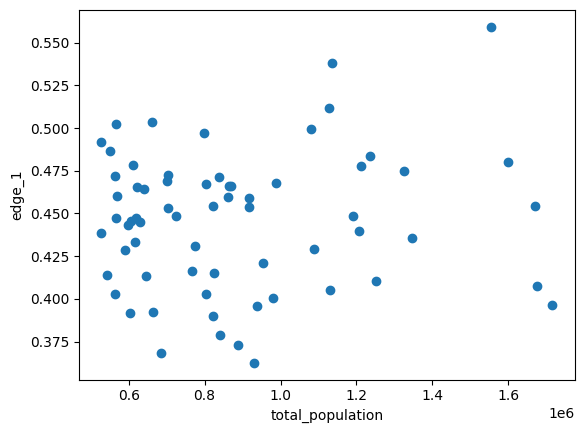

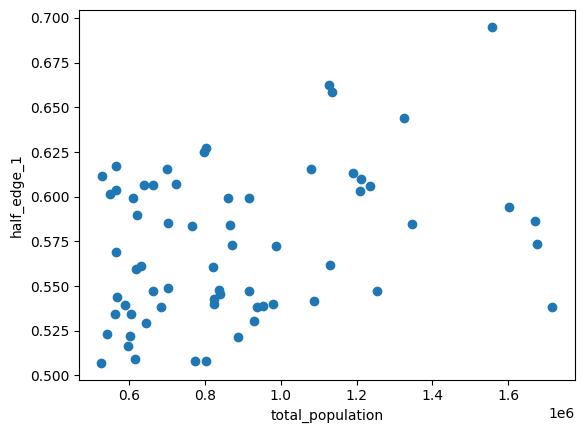

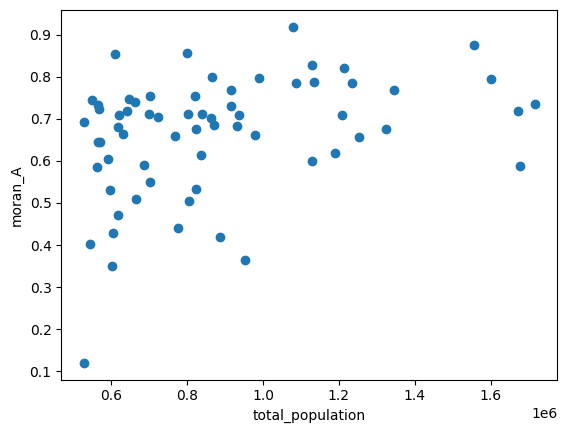

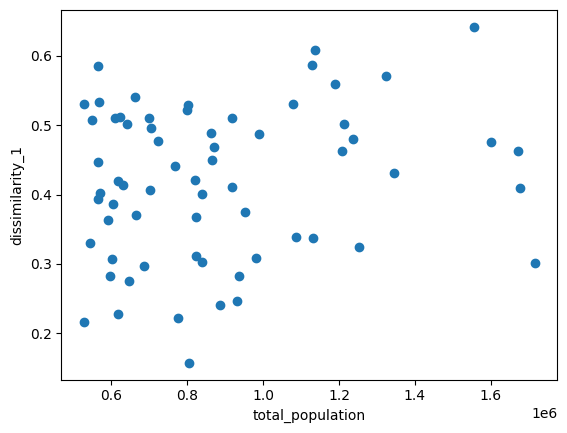

In [37]:
scores = ["edge_1", "half_edge_1", "moran_A", "dissimilarity_1"]

for score in scores:
    plotr("total_population", score, df = small_pop)

Fig 11

In [38]:
def rank_v_var(x_var, score_1, score_2, label_x = None, label_y = None, df = top_100):
    if label_x == None:
        label_x = x_var
    if label_y == None:
        label_y = label = f"{score_1} minus {score_2}"

    rank1 = df[[score_1, "cbsa_code"]].sort_values(score_1, ascending = False)
    rank2 = df[[score_2, "cbsa_code"]].sort_values(score_2, ascending = False)

    rank1 = rank1.reset_index(drop=True)
    rank1["rank_1"] = np.arange(1, len(rank1) + 1)

    rank2 = rank2.reset_index(drop=True)
    rank2["rank_2"] = np.arange(1, len(rank2) + 1)

    rank_df = rank1[["cbsa_code", "rank_1"]].merge(
        rank2[["cbsa_code", "rank_2"]],
        on="cbsa_code"
        ) 

    rank_df["rank_diff"] = rank_df["rank_1"] - rank_df["rank_2"]

    plot_df = df[["cbsa_code", x_var]].merge(
        rank_df[["cbsa_code", "rank_diff"]],
        on="cbsa_code"
        )

    plt.scatter(plot_df[x_var], plot_df["rank_diff"])

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()

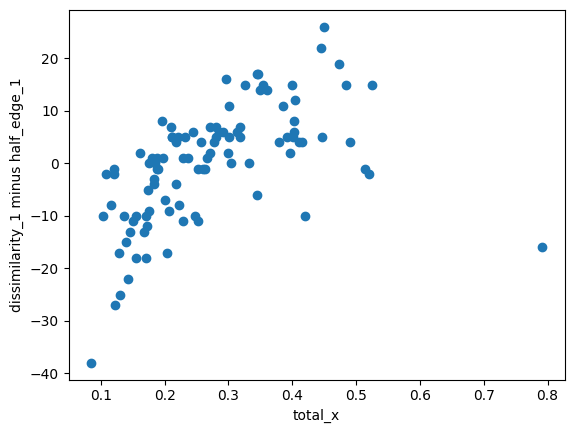

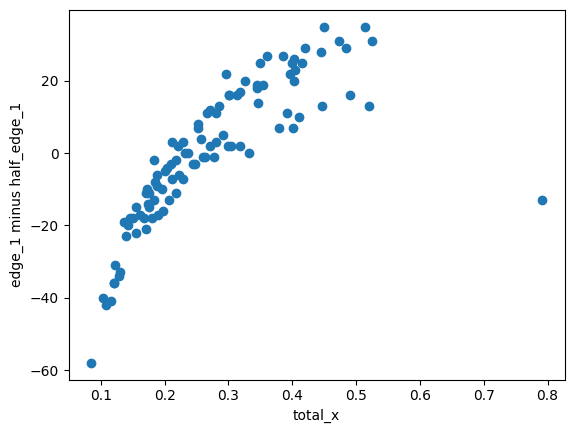

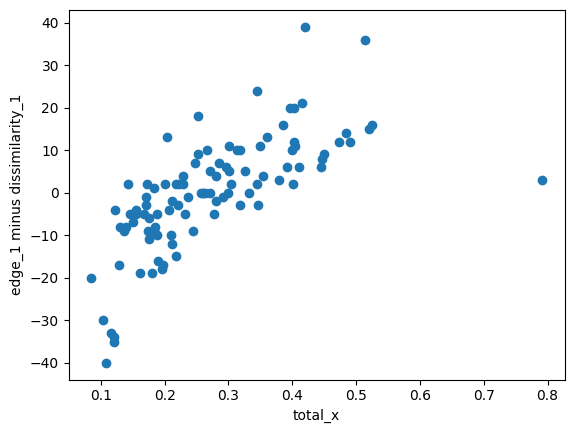

In [39]:
scores = [("dissimilarity_1", "half_edge_1"),
          ("edge_1", "half_edge_1"),
          ("edge_1", "dissimilarity_1")
    ]

for score in scores:
    rank_v_var("total_x", score[0], score[1])
    #total x is the percentage minority

Fig 9

In [43]:
def multi_rankr(x_score, y_scores, color_dict, label_x=None,  best_fit=True, df=top_100):


    if label_x is None:
        label_x = x_score

    x = (
        df[[x_score, "cbsa_code"]]
        .sort_values(x_score)
        .reset_index(drop=True)
    )

    x["rank_x"] = np.arange(1, len(x) + 1)

    for y_col in y_scores:

        y_df = (
            df[[y_col, "cbsa_code"]]
            .sort_values(y_col)
            .reset_index(drop=True)
        )

        rank_col = f"rank_{y_col}"

        y_df[rank_col] = np.arange(1, len(y_df) + 1)

        ranks = x[["cbsa_code", "rank_x"]].merge(
            y_df[["cbsa_code", rank_col]],
            on="cbsa_code"
        )

        plt.scatter(
            ranks["rank_x"],
            ranks[rank_col],
            label=y_col,
            alpha=0.7,
            c = color_dict[y_col],
            s = 5
        )

    plt.xlabel(label_x)
    plt.ylabel("Ranks of Weighted Variants")
    plt.legend()
    plt.show()

In [44]:
weights_he = ["half_edge_0", 
        "half_edge_0.5", 
        "half_edge_2", 
        "half_edge_10", 
        "half_edge_lim"]

color_dict = {"half_edge_0" : "red", 
        "half_edge_0.5" : "orange", 
        "half_edge_2" : "limegreen", 
        "half_edge_10" : "blue", 
        "half_edge_lim" : "black"
        }


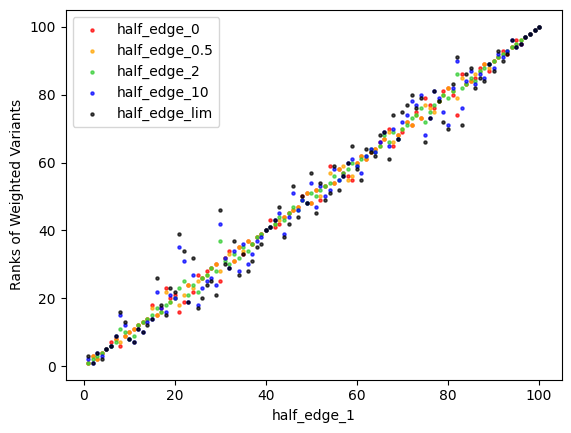

In [45]:
multi_rankr("half_edge_1", weights_he, color_dict)

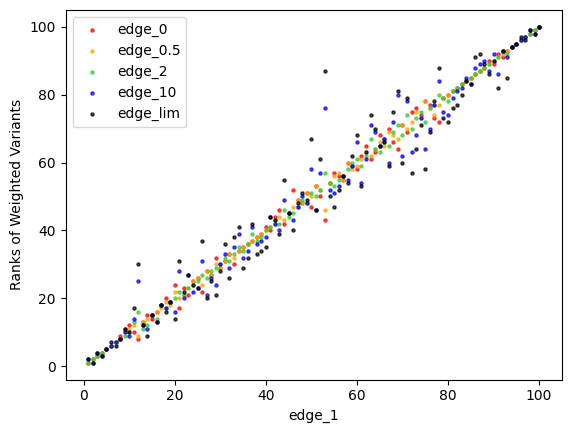

In [48]:
weights_e = ["edge_0", 
        "edge_0.5", 
        "edge_2", 
        "edge_10", 
        "edge_lim"]

color_dict = {"edge_0" : "red", 
        "edge_0.5" : "orange", 
        "edge_2" : "limegreen", 
        "edge_10" : "blue", 
        "edge_lim" : "black"
        }


multi_rankr("edge_1", weights_e, color_dict)